In [511]:
import matplotlib.pyplot as plt
from scipy.integrate import nquad
import numpy as np
from scipy.stats import linregress


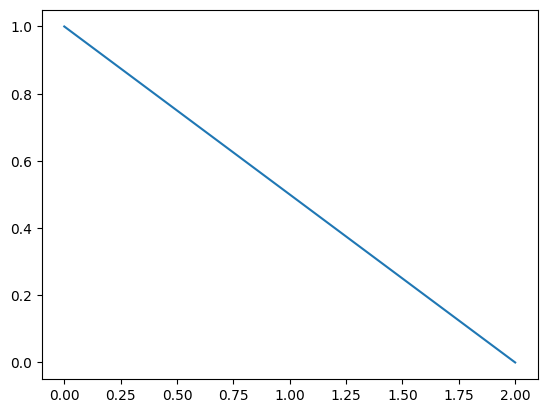

In [442]:
sig0=1.0

e0=8.854e-12
k=e0/(4*np.pi)

plt.plot(np.linspace(0,z0,100),[sigma(z) for z in np.linspace(0,z0,100)])



In [495]:
sigma=lambda z: sig0*(1 - z/z0) 

def integrand(zp, phip, rp, r, phi, z):
    #r=np.sqrt(x**2+y**2)
    #rp=np.sqrt(xp**2+yp**2)
    R=np.sqrt(r**2 + rp**2 - 2*r*rp*np.cos(phi - phip) + (z - zp)**2)
    return sigma(zp)/R

def F(rp, r , phi, z):
    #zp=0
    bounds = [[0.0, z0], [0, 2*np.pi]]
    #bounds = [[0, 2*np.pi]]
    result, err = nquad(integrand, bounds, args=(rp, r, phi, z))
    return result,err

F_vec = np.vectorize(lambda rp, r, z: F(rp, r,0,z)[0])

In [496]:
N=20
dx=0.3
dz=0.3
z0=2
a=0.5
x=np.linspace(-a-dx,a+dx,N+1)
y=x
z=np.linspace((0),z0,N+1)
deltax=x[1]-x[0]
deltaz=z[1]-z[0]
X,Y, Z=np.meshgrid(x,y,z,indexing='ij')
R=np.sqrt((X)**2 + Y**2)


In [497]:
Res=a*F_vec(a,R,Z)#*k
#vals = F_vec(xs, ys, zs)


In [498]:
Res[:,:,0]=Res[:,:,1]
Res[:,:,N]=Res[:,:,N-1]
Res[0,:,:]=Res[1,:,:]
Res[N,:,:]=Res[N-1,:,:]
Res[ :,0,:]=Res[:,1,:]
Res[:,N,:]=Res[:,N-1,:]

In [499]:
Ex,Ey,Ez=np.gradient(-Res, deltax, deltax, deltaz)

In [1]:
fig, ax = plt.subplots()

im=ax.contourf(X[:,:,0],Y[:,:,0], Res[:,:,int(N/2)], levels=100,cmap='inferno')
ax.quiver(X[:,:,int(N/2)], Y[:,:,int(N/2)],
          Ex[:,:,int(N/2)], Ey[:,:,int(N/2)],
          color='white', scale=60,figsize=(8,6))
circle = Circle(
    (0.0, 0.0),     # center (x0, y0)
    a,
    edgecolor='red',
    facecolor='none',
    linewidth=2,
    zorder=10       # ensures it is on top
)
ax.add_patch(circle)
#plt.xlim(0, 2*a)
#plt.ylim(0, 2*a)
plt.colorbar(im,ax=ax)
#im.set_clim(0, 2)
#plt.colorbar(label='Potential (arbitrary units)')


NameError: name 'plt' is not defined

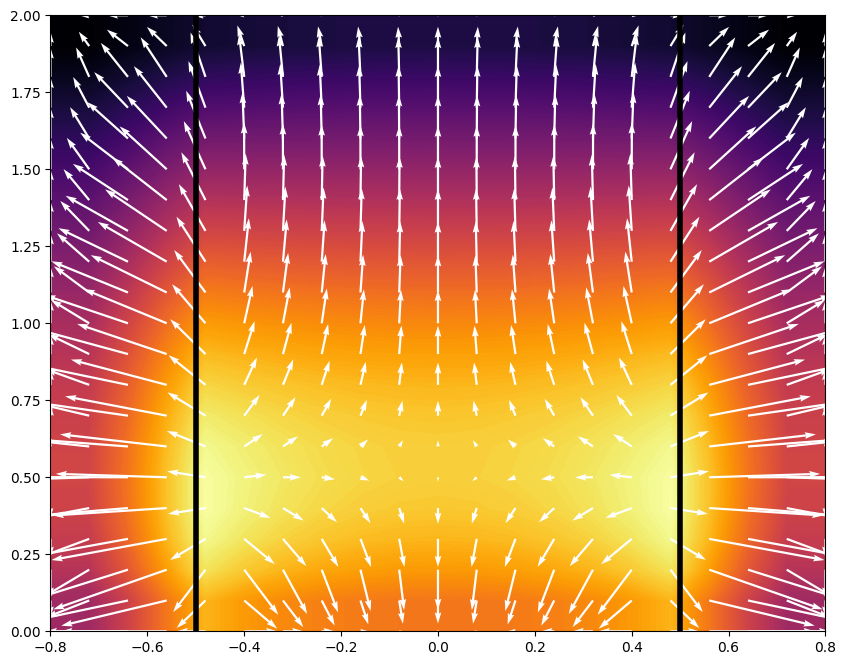

In [ ]:
idx=int(N/2)
plt.figure(figsize=(10,8))
plt.vlines([-a,a],0, z0, colors='k',lw=4)
plt.contourf(X[:,idx,:],Z[:,idx,:], Res[:,idx,:], levels=200,cmap='inferno')
plt.quiver(X[:,idx,:], Z[:,idx,:],
          Ex[:,idx,:], Ez[:,idx,:],
          color='white', scale=40)

#plt.streamplot(X[:,idx,:],Z[:,idx,:],Ex[:,idx,:],Ez[:,idx,:], color='white')




In [480]:
y[int(N/2)]

np.float64(0.0)

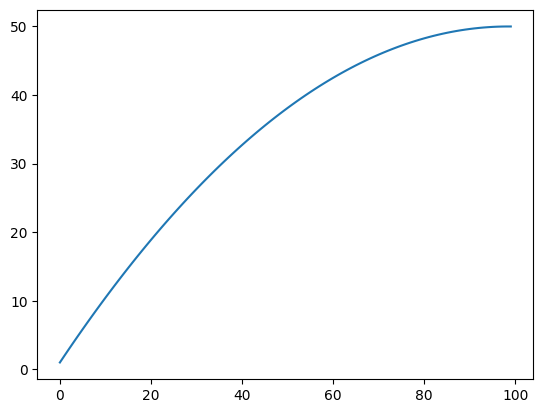

In [503]:
plt.plot(np.cumsum([sigma(z) for z in np.linspace(0,z0,100)]))

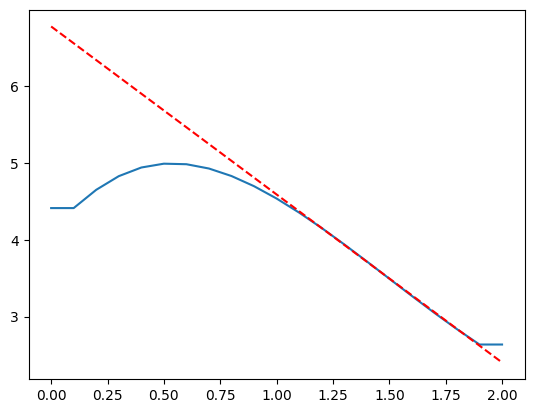

In [537]:
plt.plot(z,Res[idx,idx,:])
id1=12
tt=linregress(z[id1:-1], Res[idx,idx,id1:-1])
plt.plot(z, tt.slope*z + tt.intercept, 'r--', label=f'Slope: {tt.slope:.4f}')

In [520]:
z

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

In [532]:
N

20